In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df=pd.read_csv("/content/dirty_cafe_sales.csv")

In [8]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


# conveting data tyes of features
###quantatiy to numeric form object
###price per unit to numeric form object
###total spent to numeric form object
###transaction date to numeric form object

In [9]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9667 non-null   object        
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   object        
 6   Location          6735 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


#Handle Missing Values

In [11]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,479
Price Per Unit,533
Total Spent,502
Payment Method,2579
Location,3265
Transaction Date,460


In [12]:
# Fill missing payment & location
df["Payment Method"].fillna("Not Specified", inplace=True)
df["Location"].fillna("Not Specified", inplace=True)

# Drop rows where critical values missing
df.dropna(subset=["Quantity", "Price Per Unit"], inplace=True)

/tmp/ipython-input-411/1170243046.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Payment Method"].fillna("Not Specified", inplace=True)
/tmp/ipython-input-411/1170243046.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [13]:
df.isnull().sum()


,0
Transaction ID,0
Item,293
Quantity,0
Price Per Unit,0
Total Spent,462
Payment Method,0
Location,0
Transaction Date,410


#Fix Incorrect Totals

In [14]:
df["Revenue"]=df["Quantity"]*df["Price Per Unit"]

#Remove Duplicates

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.head()


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0


In [17]:
df['Item'].fillna('Unknown', inplace=True)

/tmp/ipython-input-411/1182951520.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item'].fillna('Unknown', inplace=True)


In [18]:
df['Transaction Date'].fillna(method='ffill', inplace=True)  # forward fill

/tmp/ipython-input-411/2836109438.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transaction Date'].fillna(method='ffill', inplace=True)  # forward fill
/tmp/ipython-input-411/2836109438.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Transaction Date'].fillna(method='ffill', inplace=True)  # forward fill


In [19]:
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,462
Payment Method,0
Location,0
Transaction Date,0
Revenue,0


In [20]:
print(df["Total Spent"])

0        4.0
1       12.0
2        NaN
3       10.0
4        4.0
        ... 
9993     NaN
9994    16.0
9995     4.0
9997     8.0
9999    12.0
Name: Total Spent, Length: 9006, dtype: float64


In [21]:

# Fill missing Total Spent by multiplying Quantity and Price per Unit
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

In [22]:
df["Total Spent"]

,Total Spent
0,4.0
1,12.0
2,4.0
3,10.0
4,4.0
...,...
9993,8.0
9994,16.0
9995,4.0
9997,8.0


In [23]:
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0
Revenue,0


#Feature Engineering

In [24]:
df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["Day"] = df["Transaction Date"].dt.day
df["Day_Name"] = df["Transaction Date"].dt.day_name()

#Exploratory Data Analysis (EDA)

In [25]:
#total revenu
total_revenue = df["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 80478.5


In [26]:
#best selling item
df["Item"].value_counts()

,count
Item,
Juice,1063
Coffee,1048
Cake,1042
Salad,1030
Sandwich,1022
Smoothie,994
Cookie,976
Tea,972
UNKNOWN,304


In [27]:
#revenue by item
df.groupby("Item")["Revenue"].sum().sort_values(ascending=False)

,Revenue
Item,
Salad,15600.0
Sandwich,12296.0
Smoothie,12132.0
Juice,9561.0
Cake,9540.0
Coffee,6424.0
Tea,4431.0
Cookie,2898.0
Unknown,2651.0


In [28]:
#revenue by location
df.groupby("Location")["Revenue"].sum().sort_values(ascending=False)

,Revenue
Location,
Not Specified,26606.5
In-store,24598.0
Takeaway,23868.0
ERROR,2906.0
UNKNOWN,2500.0


In [29]:
#payment method distribution
df["Payment Method"].value_counts()

,count
Payment Method,
Not Specified,2310
Digital Wallet,2068
Credit Card,2047
Cash,2044
ERROR,271
UNKNOWN,266


#Visualizations

##Monthly Revenue Trend


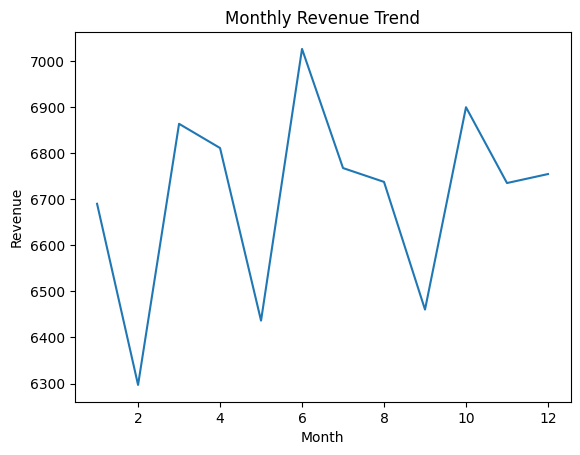

In [36]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure()
monthly_sales.plot(kind="line")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Revenue By item


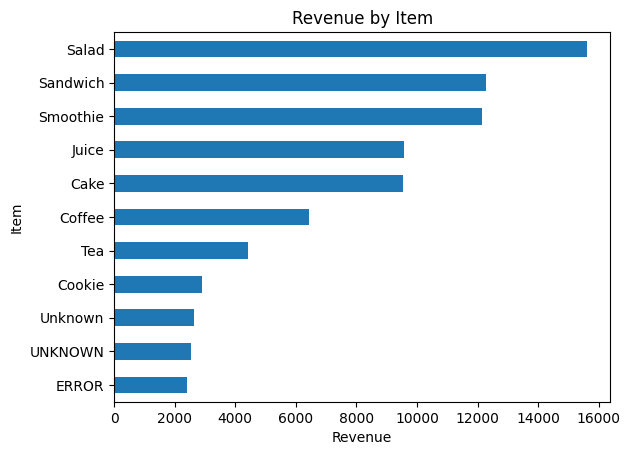

In [31]:
item_revenue = df.groupby("Item")["Revenue"].sum().sort_values()

plt.figure()
item_revenue.plot(kind="barh")
plt.title("Revenue by Item")
plt.xlabel("Revenue")
plt.show()

#Top & Bottom Products
Objective:

Best-selling product

Worst-selling product

Highest revenue product

In [38]:
# Total Quantity Sold per Product
product_sales = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)

print("Top 5 Products by Quantity:")
print(product_sales.head())

print("\nBottom 5 Products by Quantity:")
print(product_sales.tail())

# Revenue per Product
product_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

print("\nTop 5 Products by Revenue:")
print(product_revenue.head())

Top 5 Products by Quantity:
Item
Coffee      3212.0
Juice       3187.0
Cake        3180.0
Salad       3120.0
Sandwich    3074.0
Name: Quantity, dtype: float64

Bottom 5 Products by Quantity:
Item
Tea        2954.0
Cookie     2898.0
UNKNOWN     883.0
Unknown     883.0
ERROR       806.0
Name: Quantity, dtype: float64

Top 5 Products by Revenue:
Item
Salad       15600.0
Sandwich    12296.0
Smoothie    12132.0
Juice        9561.0
Cake         9540.0
Name: Total Spent, dtype: float64


#Peak Hours Analysis

In [42]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'Revenue', 'Year',
       'Month', 'Day', 'Day_Name'],
      dtype='object')

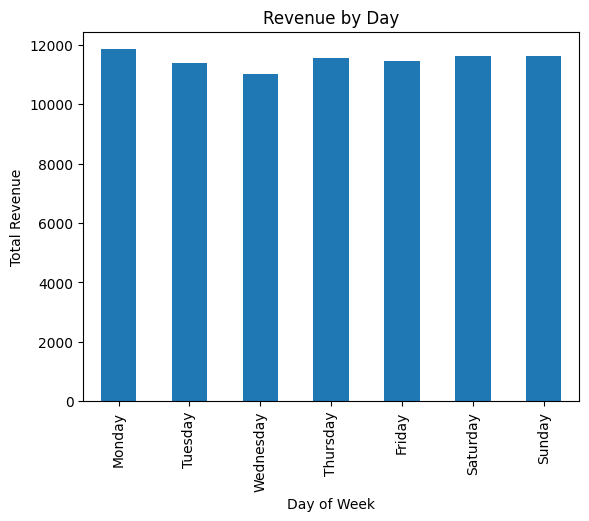

Busiest Day: Monday


In [45]:
# Calculate revenue by day
daily_revenue = df.groupby('Day_Name')['Total Spent'].sum()

# Arrange days in correct order
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_revenue = daily_revenue.reindex(order)

# Plot
plt.figure()
daily_revenue.plot(kind='bar')
plt.title("Revenue by Day")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.show()

# Find busiest day
busiest_day = daily_revenue.idxmax()
print("Busiest Day:", busiest_day)

In [48]:
df.to_csv('clean_cafe_sales.csv', index=False)
from google.colab import files
files.download('clean_cafe_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
dff=pd.read_csv("/content/clean_cafe_sales.csv")

In [50]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9006 entries, 0 to 9005
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9006 non-null   object 
 1   Item              9006 non-null   object 
 2   Quantity          9006 non-null   float64
 3   Price Per Unit    9006 non-null   float64
 4   Total Spent       9006 non-null   float64
 5   Payment Method    9006 non-null   object 
 6   Location          9006 non-null   object 
 7   Transaction Date  9006 non-null   object 
 8   Revenue           9006 non-null   float64
 9   Year              9006 non-null   int64  
 10  Month             9006 non-null   int64  
 11  Day               9006 non-null   int64  
 12  Day_Name          9006 non-null   object 
dtypes: float64(4), int64(3), object(6)
memory usage: 914.8+ KB


In [52]:
dff.describe()

,Quantity,Price Per Unit,Total Spent,Revenue,Year,Month,Day
count,9006.000000,9006.000000,9006.000000,9006.000000,9006.0,9006.000000,9006.000000
mean,3.023540,2.951865,8.936098,8.936098,2023.0,6.521652,15.714524
std,1.418644,1.277659,5.994375,5.994375,0.0,3.446413,8.750696
min,1.000000,1.000000,1.000000,1.000000,2023.0,1.000000,1.000000
25%,2.000000,2.000000,4.000000,4.000000,2023.0,4.000000,8.000000
50%,3.000000,3.000000,8.000000,8.000000,2023.0,7.000000,16.000000
75%,4.000000,4.000000,12.000000,12.000000,2023.0,10.000000,23.000000
max,5.000000,5.000000,25.000000,25.000000,2023.0,12.000000,31.000000
